## Understanding Bias-Variance Trade-off

In machine learning, the **Bias-Variance Trade-off** is a central concept that helps us understand how well our models generalize to new, unseen data.

### 1. Bias (Underfitting)
Bias refers to the simplifying assumptions made by a model to make the target function easier to learn. A high-bias model makes strong assumptions about the data, often overlooking crucial relationships between features and the target output. This leads to **underfitting**, where the model is too simple to capture the underlying patterns in the training data, resulting in poor performance on both training and test data.

*   **Characteristics:** Simple models (e.g., linear regression on non-linear data), consistently misses patterns, high error on training and test data.

### 2. Variance (Overfitting)
Variance refers to the model's sensitivity to small fluctuations or noise in the training data. A high-variance model is overly complex and learns the noise and specific details of the training data rather than the general trend. This leads to **overfitting**, where the model performs exceptionally well on the training data but poorly on new, unseen data because it has memorized the training examples rather than learned the generalized relationships.

*   **Characteristics:** Complex models (e.g., high-degree polynomial regression), captures noise, low error on training data but high error on test data.

### 3. The Trade-off
The goal is to find a model that has both low bias and low variance. However, these two properties are often in tension: reducing bias often increases variance, and reducing variance often increases bias. This is the **Bias-Variance Trade-off**.

*   **High Bias, Low Variance:** The model is consistent but inaccurate on average.
*   **Low Bias, High Variance:** The model is accurate on average but inconsistent (highly sensitive to specific training data).
*   **Optimal Balance:** The "sweet spot" where the model achieves a good balance between bias and variance, performing well on both training and unseen data.

### How this worksheet demonstrates it:
*   **High Bias (Underfitting - Degree 1):** A simple linear model (degree 1) is too rigid to capture the sine wave pattern, resulting in high error.
*   **Sweet Spot (Optimal Balance - Degree 3):** A polynomial of degree 3 offers enough flexibility to fit the sine wave while avoiding noise, showing a good balance.
*   **High Variance (Overfitting - Degree 15):** A high-degree polynomial (degree 15) tries to fit every data point, including the noise, leading to an overly complex curve that would generalize poorly to new data, despite fitting the training data very well.

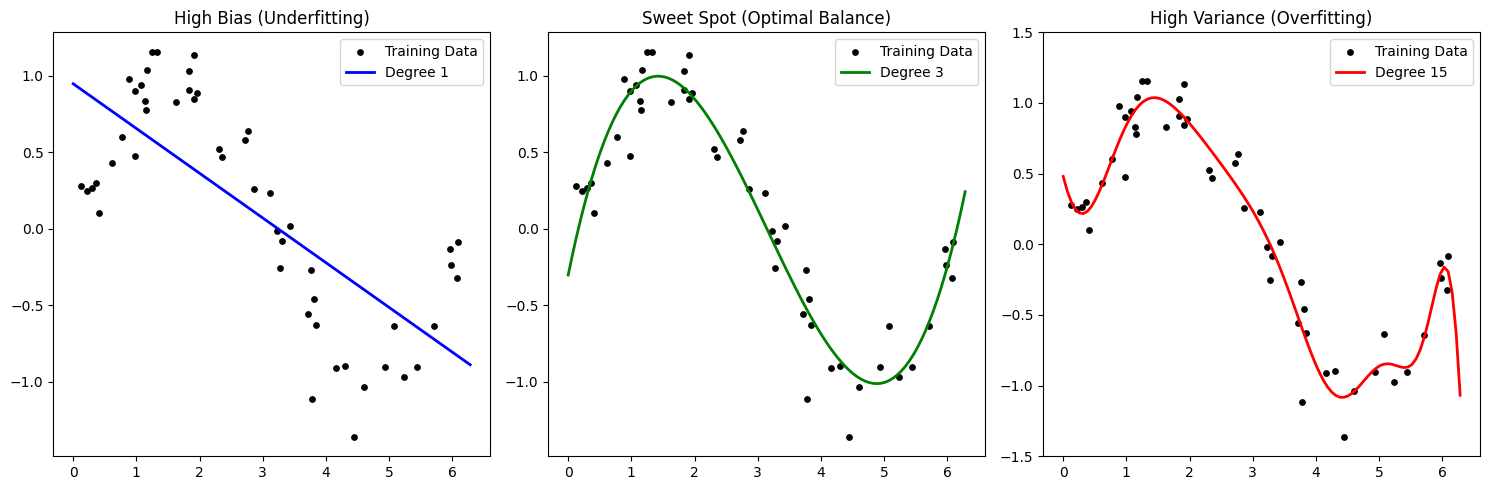

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Generate a complex, non-linear dataset (a sine wave with noise)
np.random.seed(42)
# Generate 50 random x values between 0 and 2*pi
X = np.sort(np.random.rand(50) * 2 * np.pi).reshape(-1, 1)
# The true relationship is a sine wave, plus some random static (noise)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 50)

# Generate a perfectly smooth set of x values just for drawing our lines later
X_plot = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)

# 2. Setup the plot
plt.figure(figsize=(15, 5))

# --- MODEL 1: High Bias (Underfitting) ---
# Forcing a straight line (Degree 1) onto a curvy dataset
plt.subplot(1, 3, 1)
model_bias = LinearRegression()
model_bias.fit(X, y)
plt.scatter(X, y, color='black', s=15, label="Training Data")
plt.plot(X_plot, model_bias.predict(X_plot), color='blue', linewidth=2, label="Degree 1")
plt.title("High Bias (Underfitting)")
plt.legend()

# --- MODEL 2: The Sweet Spot (Optimal Balance) ---
# Allowing the line to bend slightly (Degree 3)
plt.subplot(1, 3, 2)
# We use a pipeline to quickly turn our X feature into X^1, X^2, X^3
model_optimal = make_pipeline(PolynomialFeatures(3), LinearRegression())
model_optimal.fit(X, y)
plt.scatter(X, y, color='black', s=15, label="Training Data")
plt.plot(X_plot, model_optimal.predict(X_plot), color='green', linewidth=2, label="Degree 3")
plt.title("Sweet Spot (Optimal Balance)")
plt.legend()

# --- MODEL 3: High Variance (Overfitting) ---
# Giving the model too much flexibility (Degree 15)
plt.subplot(1, 3, 3)
model_variance = make_pipeline(PolynomialFeatures(15), LinearRegression())
model_variance.fit(X, y)
plt.scatter(X, y, color='black', s=15, label="Training Data")
# We limit the y-axis because this line will violently shoot off the screen
plt.plot(X_plot, model_variance.predict(X_plot), color='red', linewidth=2, label="Degree 15")
plt.ylim(-1.5, 1.5)
plt.title("High Variance (Overfitting)")
plt.legend()

plt.tight_layout()
plt.show()